# VARYPED Equilibrium Scan Example

Demonstrates the `varyped` module for creating equilibrium scans of self-consistently scaled pressure and current density profiles using input
g-files and p-files.  

**What this notebook covers:**
1. Loading TokaMaker and input files
2. Running scan with single scale value
3. Running a full equilibrium scan with various scaling values
4. Comparing original vs scaled profiles


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=(10,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [2]:
tokamaker_python_path = 'PATH_TO_OFT'
tokamaker_python_path = os.getenv("OFT_ROOTPATH")
#PATH_TO_OFT should be replaced with where your OFT is installed

if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))

from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker, meshing, eqdsk
import varyped

## 1. Loading TokaMaker and input files

In [3]:
#Loading gfile using eqdsk.py
gfile = 'TkMkr_D3Dlike_Hmode_BSamp=1.0.geqdsk'
g_eq = eqdsk.read_geqdsk(gfile)

#Loading TokaMaker object
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)
mygs.settings.maxits = 200

mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = meshing.load_gs_mesh('DIIID_mesh.h5') ##D3D mesh loaded in
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.setup(order=2,F0=abs(g_eq.R_center*g_eq.B_center))
mygs.set_coil_vsc({'F9A': 1.0, 'F9B': -1.0})

isoflux_pts = np.column_stack((g_eq.boundary_R, g_eq.boundary_Z))
weights = np.ones(len(isoflux_pts))*100.
mygs.set_isoflux_constraints(isoflux_pts, weights) ##isoflux and isoflux weights set

#Loading pfile using eqdsk.py
pfile = 'TkMkr_D3Dlike_Hmode_BSamp=1.0.peqdsk'
p_eq = eqdsk.read_pfile(pfile)


#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           51794ed
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Integer Precisions    =    4   8
Float Precisions      =    4   8  10
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.574E+01
    # of points  =    8910
    # of edges   =   26567
    # of cells   =   17658
    # of boundary points =     160
    # of boundary edges  =     160
    # of boundary cells  =     160
  Resolution statistics:
    hmin =  8.702E-04
    hrms =  4.833E-02
    hmax =  1.540E-01
  Surface grounded at vertex    1733


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    2.7

In [4]:
target_currents = {
    'ECOILA': -0.977888676757812/61.0,
    'ECOILB': -0.962711173828125/61.0,
    'F1A': 0.115971984375,
    'F2A': 0.05980789453125,
    'F3A': -0.03076001171875,
    'F4A': -0.0401077421875,
    'F5A': 0.000723009033203125,
    'F6A': -0.1178582568125,
    'F7A': 0.0341264296875,
    'F8A': -0.05660116015625,
    'F9A': 0.236625375,
    'F1B': 0.128368578125,
    'F2B': 0.0763701328125,
    'F3B': -0.02234583203125,
    'F4B': -0.13314096875,
    'F5B': 0.000399709045410156,
    'F6B': -0.15356990625,
    'F7B': 0.0415082109375,
    'F8B': -0.05138975390625,
    'F9B': 0.252380265625
}
for key in target_currents:
    target_currents[key] *= 1.E6

# Set regularization weights
regularization_terms = []
for name, target_current in target_currents.items():
    # Set specific target currents from input equilibrium and different weights depending on the coil set
    if name.startswith('ECOIL'):
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=target_current,weight=1.0))
    elif name.startswith('F'):
        if name.startswith('F5'):
            regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=target_current,weight=1.))
        else:
            regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=target_current,weight=1.))
# Set zero target current and small weight on virtual VSC to allow up-down adjustment
regularization_terms.append(mygs.coil_reg_term({'#VSC': 1.0},target=0.0,weight=1.E-2))

# Pass regularization terms to TokaMaker
mygs.set_coil_reg(reg_terms=regularization_terms)

## Function Syntax

An equilibrium scan is performed by calling `varyped.equilibrium_scan` with the following parameters:
- `t_object`: TokaMaker Grad-Shafranov Solver Object
- `pfile`: p-file object containing input kinetic profiles
- `gfile`: g-file object containing standard GEQDSK equilibrium data
- `scaling_values`: array-like object of non-decreasing positive scalar values
- `path_to_output`: (str) path to directory where outputs will be created, defaults to the current working directory
- `filenames`: (str) name for output files (typically of the form #####.####, where # are integers), defaults to 10000.0000
- `file_output`: Boolean value that will determine if equilibrium scan generates output files

The `equilibrium_scan` function also returns a list of dictionaries so that certain run results can be easily retreived. The returned value can also be passed into `varyped.plot_varyped_results` to plot the resulting pressure, current density, and pressure derivative profiles. Each dictionary contains the following information:
- `scale_p`: Pressure Pedestal scaling factor
- `scale_j`: Current Density Edge Spike scaling factor
- `gfile_name`: Name of the output g-file for the given pressure-current scaling value pair 
- `pfile_name`: Name of the output p-file for the given pressure-current scaling value pair
- `Ip_target`: Target total plasma current 
- `Ip_final`: Achieved total plasma current 
- `pax_target`: Target pressure on axis 
- `W_target`: Target total work stored in plasma
- `W_final`: Achieved total work stored in plasma
- `eq_snapshot`: TokaMaker_equilibrium object, snapshot of equilibria for given pressure-current scaling value pair

## 2. Running a scan with a single scaling value

In [5]:
no_scaling = 1 #Inputting a single float scaling value is handled as well
no_scaling_results = varyped.equilibrium_scan(mygs, 
                                              p_eq, 
                                              g_eq, 
                                              no_scaling, 
                                              path_to_output=None, 
                                              filenames=None)

Scaling Values Array: [1]
[equilibrium_scan] Using pfile psi_n: 514 points (pfile has higher resolution than gfile: 257)
Starting non-linear GS solver
     1  1.0000E+00 -4.3544E-06  1.1906E-02  1.7234E+00 -4.4657E-02  2.1312E+05
     2  1.0000E+00 -4.2248E-06  6.8743E-03  1.7149E+00 -3.3594E-02  1.5958E+05
     3  1.0000E+00 -4.3318E-06  4.6931E-03  1.7110E+00 -2.5880E-02  1.3859E+05
     4  1.0000E+00 -4.4367E-06  2.6593E-03  1.7092E+00 -2.0735E-02  1.3215E+05
     5  1.0000E+00 -4.5082E-06  1.5694E-03  1.7083E+00 -1.7394E-02  1.2847E+05
     6  1.0000E+00 -4.5527E-06  8.9651E-04  1.7079E+00 -1.5257E-02  1.2647E+05
     7  1.0000E+00 -4.5793E-06  5.8943E-04  1.7077E+00 -1.3803E-02  1.2489E+05
     8  1.0000E+00 -4.5951E-06  3.0156E-04  1.7076E+00 -1.2948E-02  1.2409E+05
     9  1.0000E+00 -4.6044E-06  2.1100E-04  1.7075E+00 -1.2408E-02  1.2354E+05
    10  1.0000E+00 -4.6099E-06  1.3396E-04  1.7075E+00 -1.2068E-02  1.2325E+05
    11  1.0000E+00 -4.6132E-06  9.0325E-05  1.7075E+00 -1.1

In [ ]:
scaling_up = 1.5 

filenames_scale_up = '_scaled_up_example'

scaling_up_results = varyped.equilibrium_scan(mygs, 
                                              p_eq, 
                                              g_eq, 
                                              scaling_up, 
                                              path_to_output=None, 
                                              filenames=filenames_scale_up,
                                              file_output=False)

Scaling Values Array: [1.5]
[equilibrium_scan] Using pfile psi_n: 514 points (pfile has higher resolution than gfile: 257)
Starting non-linear GS solver
     1  1.0000E+00 -4.5201E-06  1.3554E-02  1.7222E+00 -4.4045E-02  2.3664E+05
     2  1.0000E+00 -4.3945E-06  8.5534E-03  1.7137E+00 -3.2468E-02  1.6601E+05
     3  1.0000E+00 -4.5231E-06  5.2547E-03  1.7099E+00 -2.4822E-02  1.4380E+05
     4  1.0000E+00 -4.6493E-06  3.5318E-03  1.7082E+00 -1.9910E-02  1.3418E+05
     5  1.0000E+00 -4.7385E-06  2.2759E-03  1.7073E+00 -1.6816E-02  1.2860E+05
     6  1.0000E+00 -4.7971E-06  1.3882E-03  1.7069E+00 -1.4892E-02  1.2558E+05
     7  1.0000E+00 -4.8349E-06  7.4165E-04  1.7067E+00 -1.3592E-02  1.2392E+05
     8  1.0000E+00 -4.8590E-06  4.3761E-04  1.7066E+00 -1.2863E-02  1.2277E+05
     9  1.0000E+00 -4.8746E-06  2.9802E-04  1.7066E+00 -1.2416E-02  1.2204E+05
    10  1.0000E+00 -4.8851E-06  2.1052E-04  1.7065E+00 -1.2142E-02  1.2159E+05
    11  1.0000E+00 -4.8922E-06  1.2891E-04  1.7065E+00 -1

## 3. Running a full equilibrium scan

In [7]:
#a scaling values array of length n will produce 2*(n^2) output files,
#so file_output is toggled to False for this example!
scaling_values = np.linspace(0.5, 1.5, 11)

#an example for how files can be named
filenames_ex_full_run = '_full_run_example'

scaling_results = varyped.equilibrium_scan(mygs, 
                                           p_eq, 
                                           g_eq, 
                                           scaling_values, 
                                           path_to_output=None, 
                                           filenames=filenames_ex_full_run,
                                           file_output=False)

Scaling Values Array: [0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5]
[equilibrium_scan] Using pfile psi_n: 514 points (pfile has higher resolution than gfile: 257)
Starting non-linear GS solver
     1  1.0000E+00 -4.2498E-06  1.1012E-02  1.7243E+00 -4.5490E-02  1.9042E+05
     2  1.0000E+00 -4.0854E-06  5.4103E-03  1.7160E+00 -3.4769E-02  1.4982E+05
     3  1.0000E+00 -4.1629E-06  4.2064E-03  1.7121E+00 -2.6980E-02  1.3066E+05
     4  1.0000E+00 -4.2439E-06  2.4511E-03  1.7101E+00 -2.1608E-02  1.2432E+05
     5  1.0000E+00 -4.2979E-06  1.2718E-03  1.7092E+00 -1.8017E-02  1.2137E+05
     6  1.0000E+00 -4.3295E-06  7.8633E-04  1.7088E+00 -1.5659E-02  1.1954E+05
     7  1.0000E+00 -4.3472E-06  4.7632E-04  1.7086E+00 -1.4039E-02  1.1849E+05
     8  1.0000E+00 -4.3568E-06  2.9307E-04  1.7085E+00 -1.3046E-02  1.1776E+05
     9  1.0000E+00 -4.3621E-06  1.7114E-04  1.7085E+00 -1.2403E-02  1.1735E+05
    10  1.0000E+00 -4.3649E-06  1.0399E-04  1.7084E+00 -1.1988E-02  1.1710E+05
    11  1.0000E+0

## 4. Comparing and Plotting Results

This module contains a plotting function titled `varyped.plot_varyped_results` that accepts the *results* array returned by an equilibrium scan and plots the pressure, pressure derivative, and current profiles that are produced. The only parameters of the function is:

- `results`: Varyped quick results array from running an equilibrium scan. The first entry in the array contains the scaling values used for the run, the input gfile object, and the input pfile object.


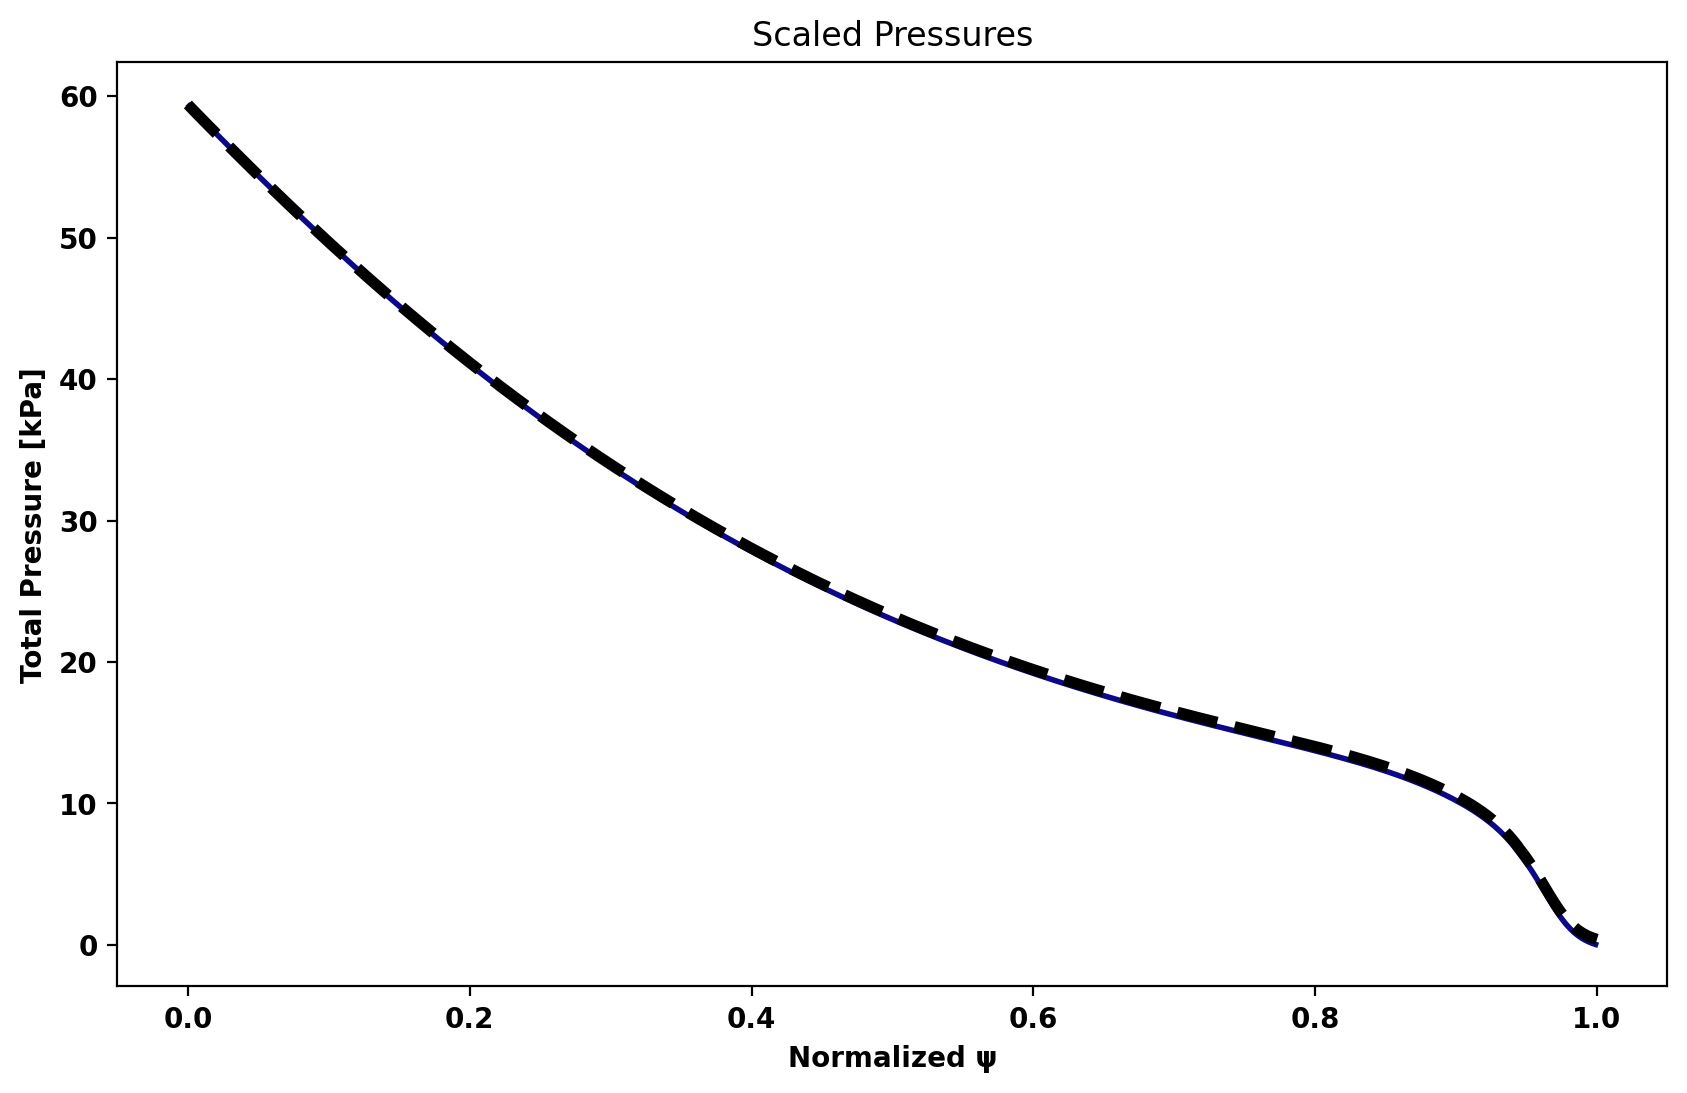

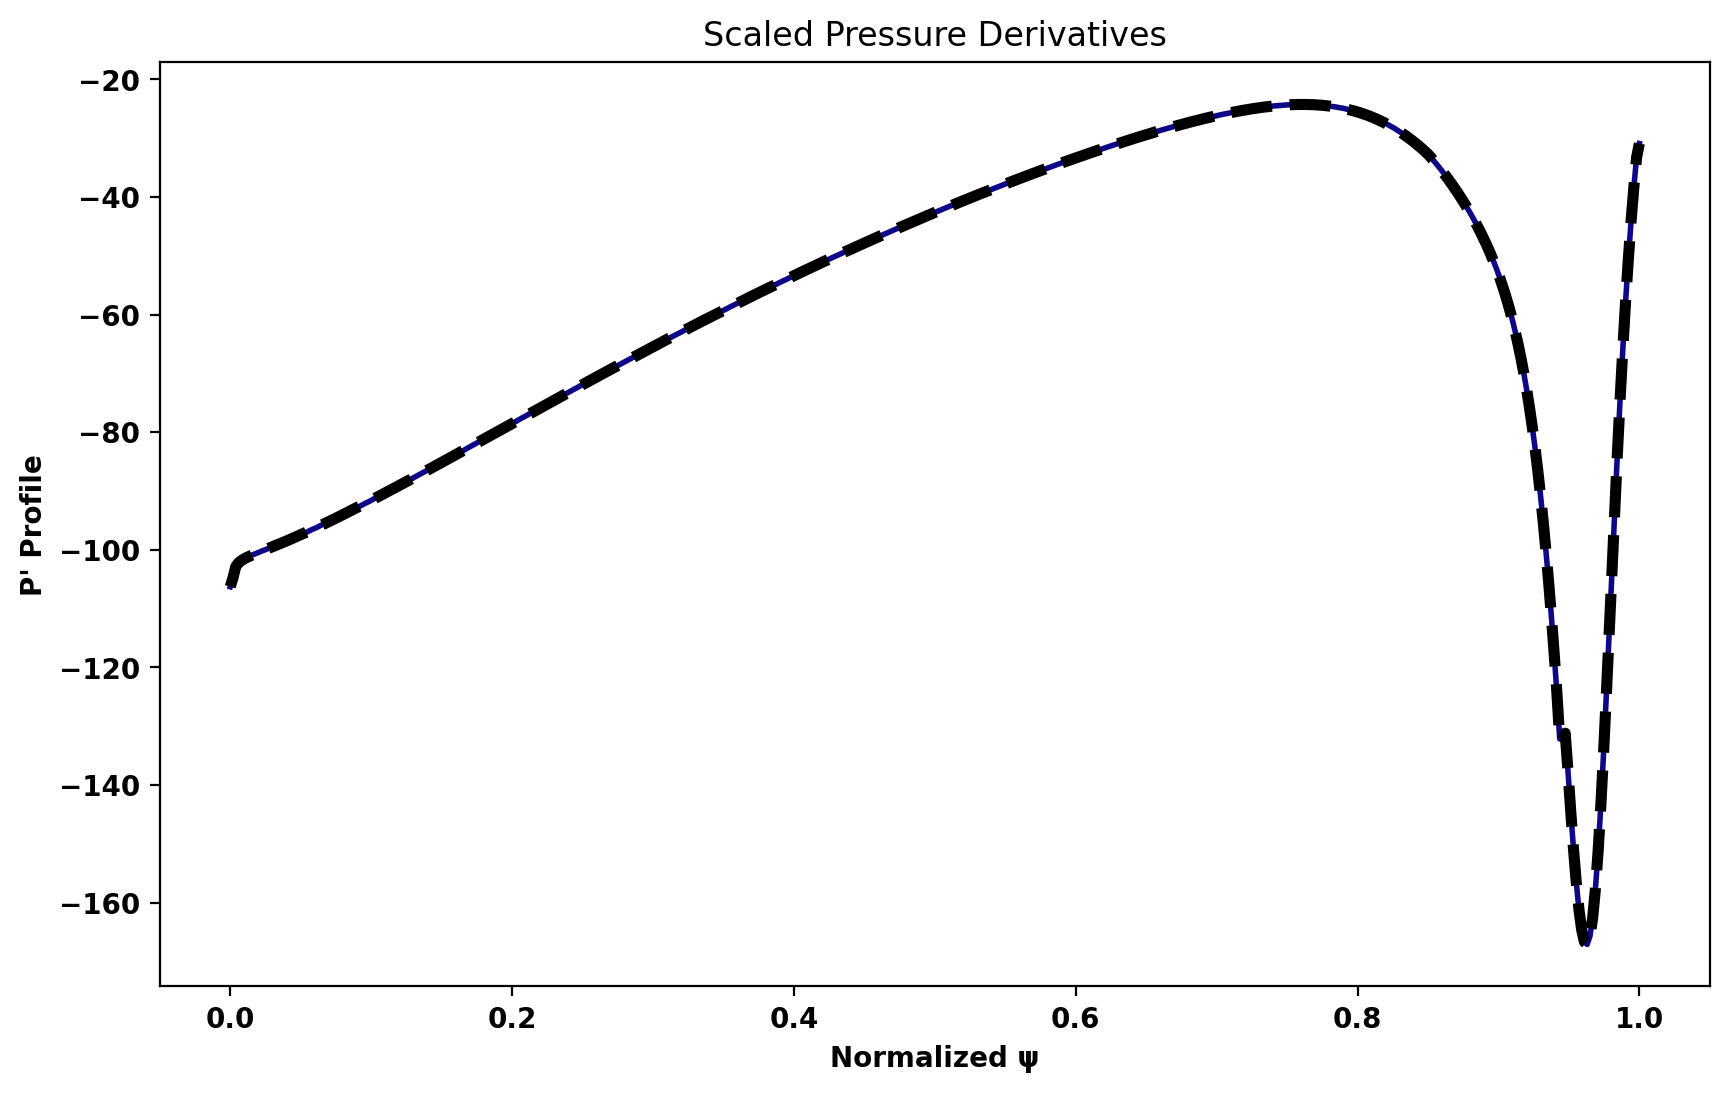

In [ ]:
#Pressure plots for no scaling
varyped.plot_pressure_results(no_scaling_results)


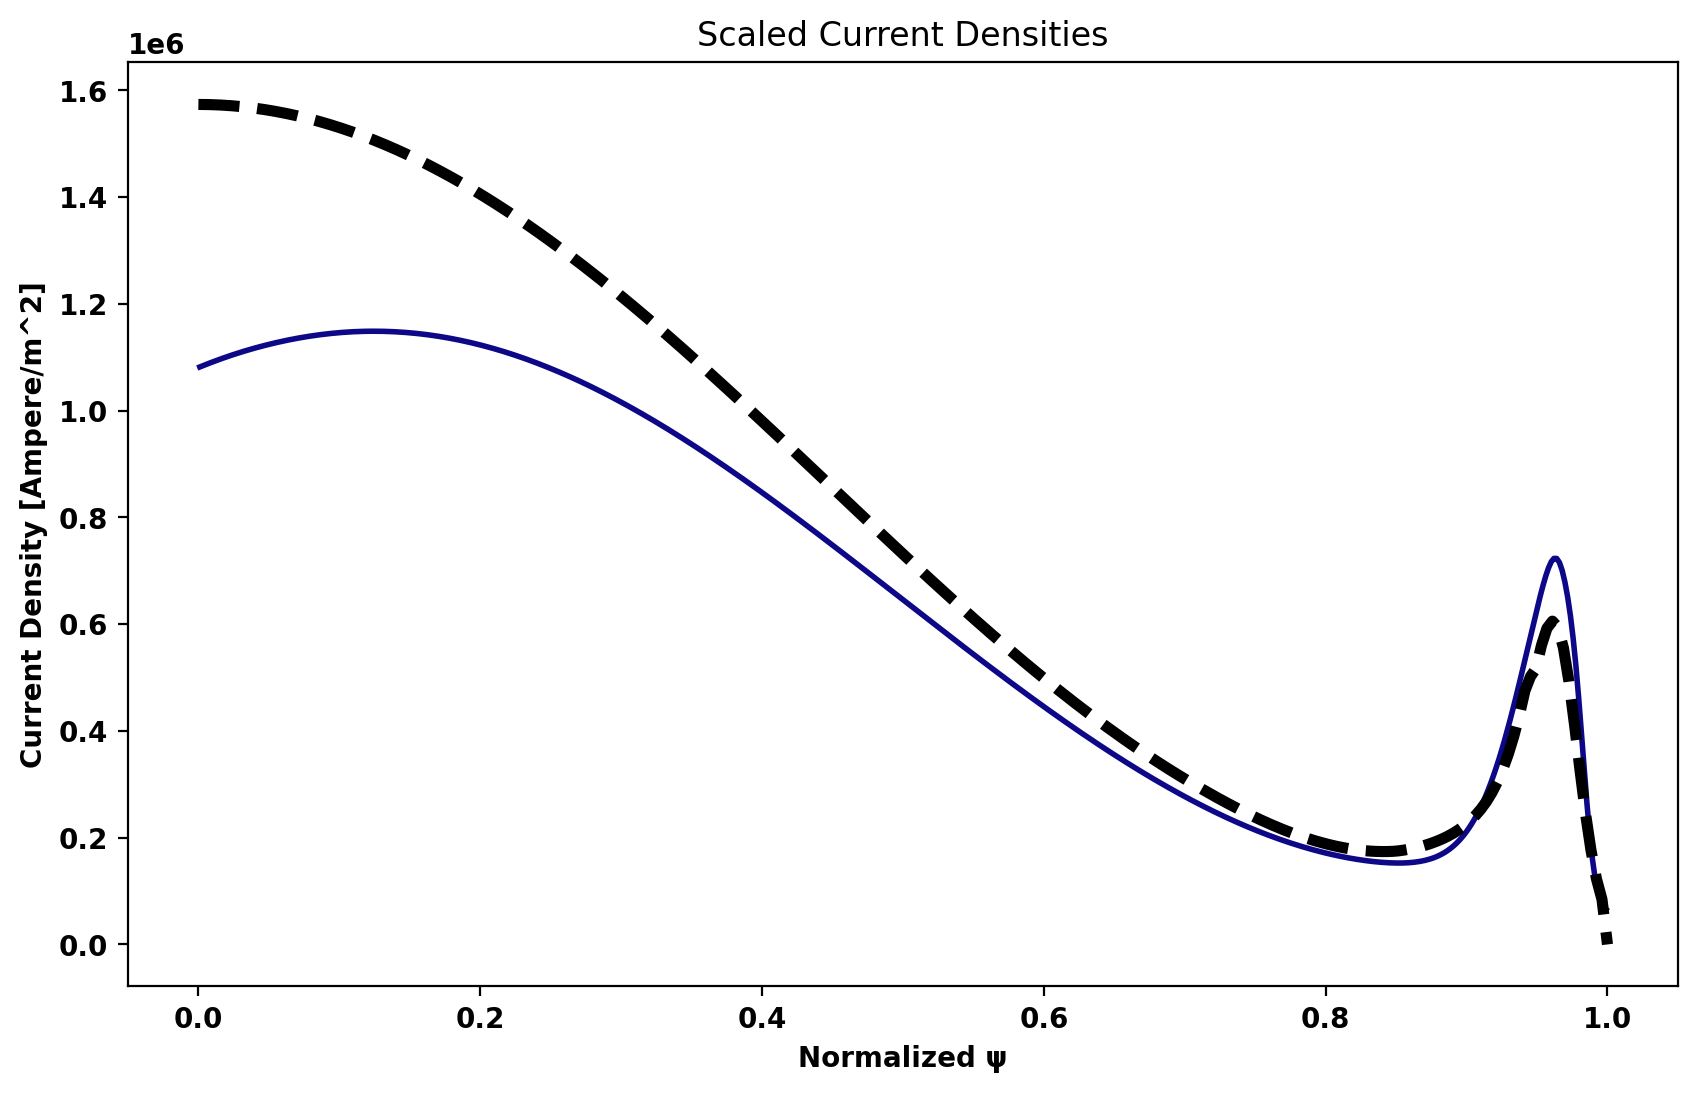

In [ ]:
#Current density plot for scaling up 
varyped.plot_current_results(scaling_up_results)


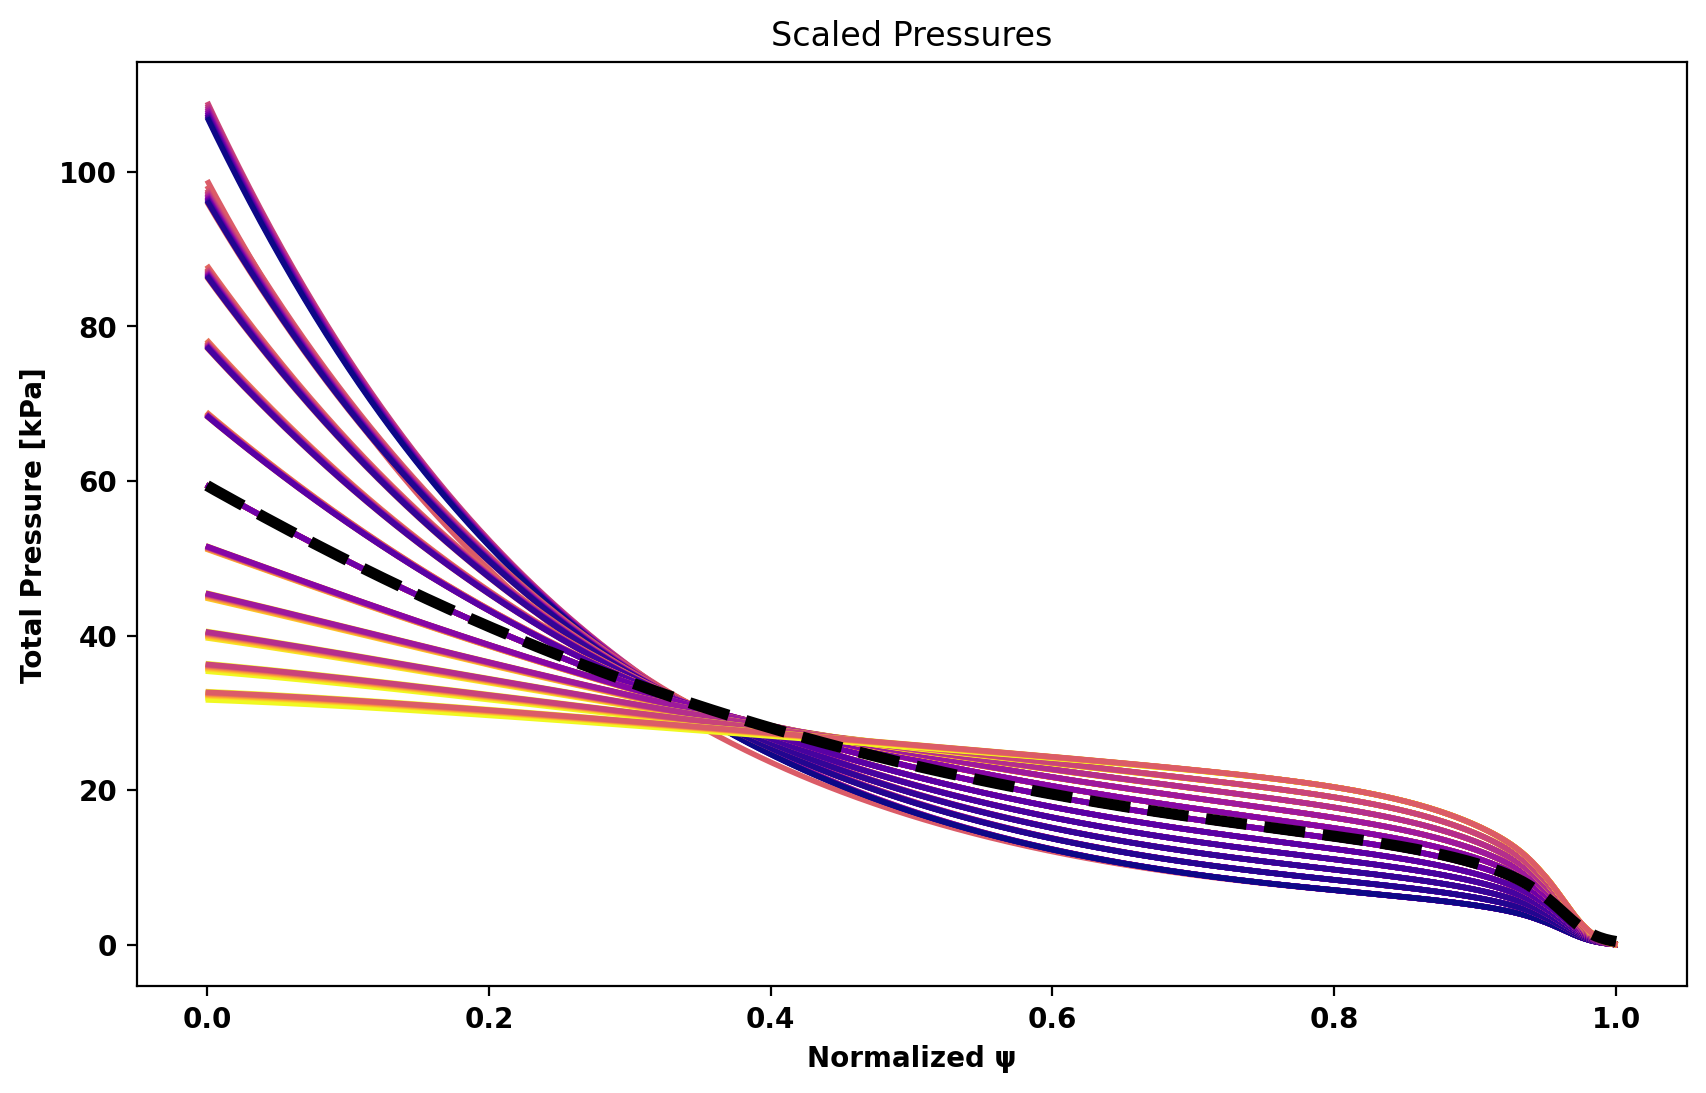

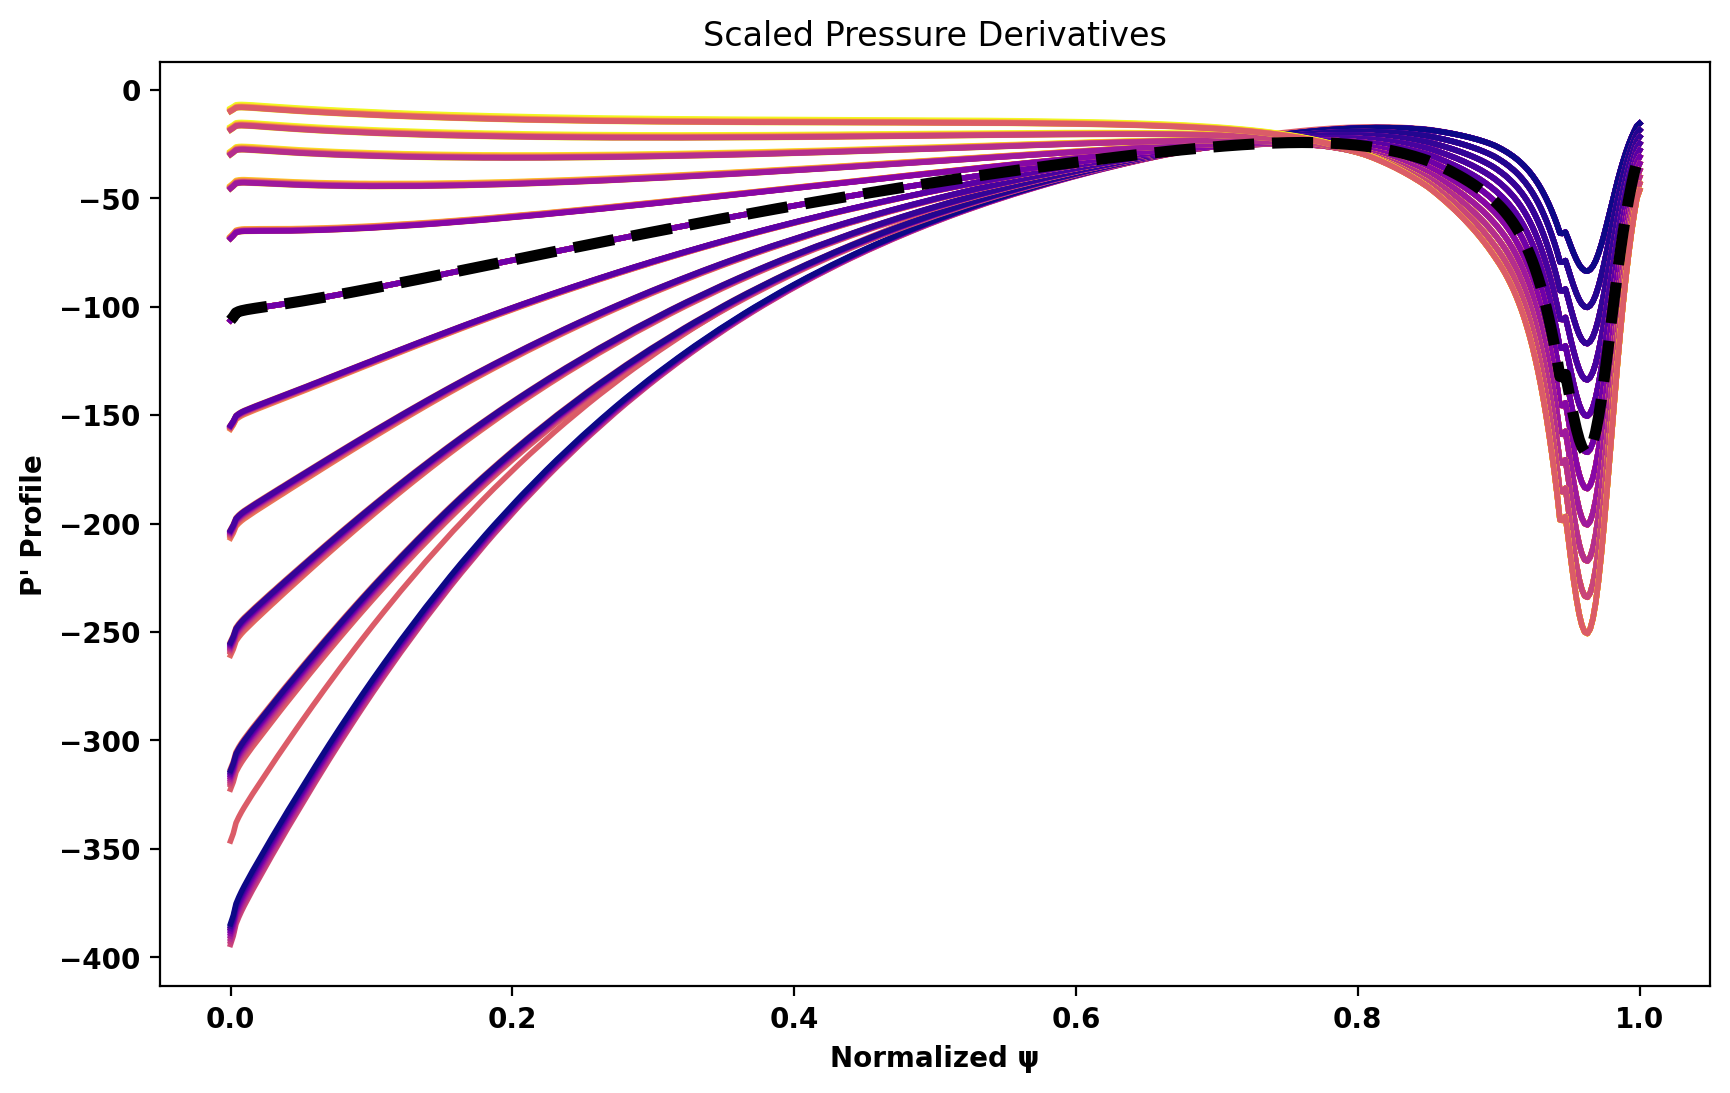

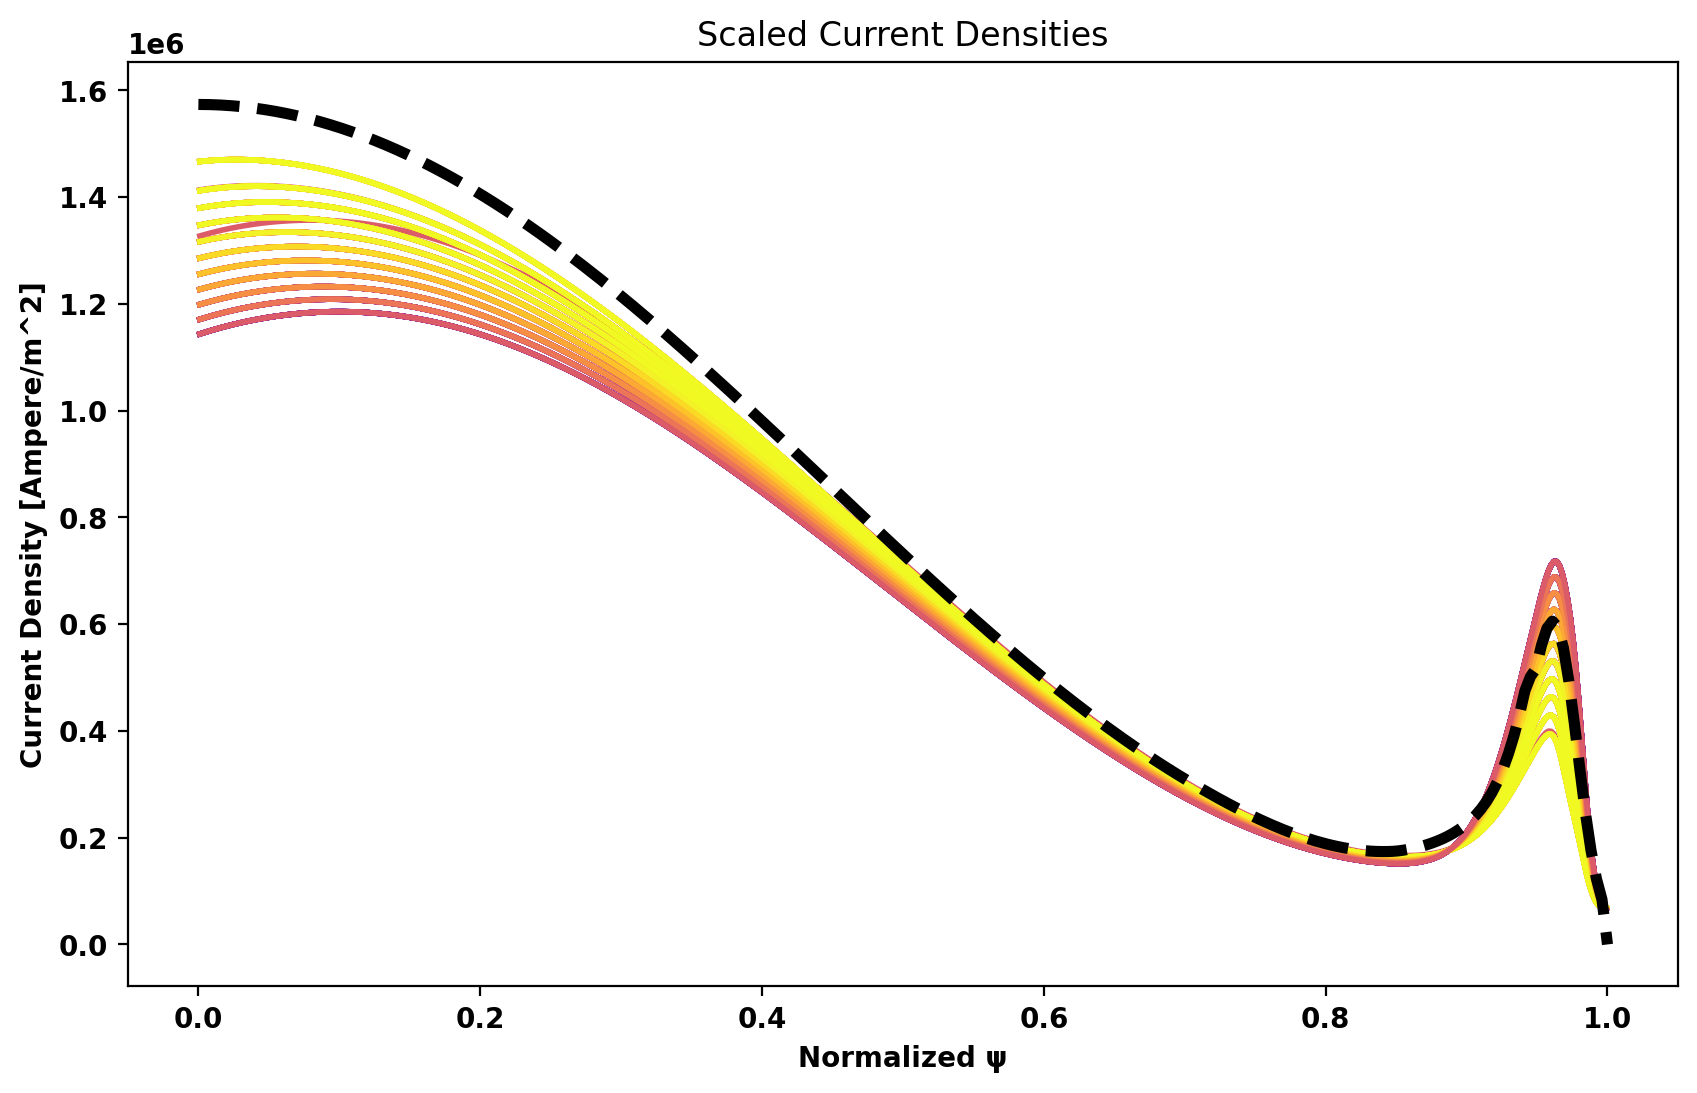

In [ ]:
#Plot for full equilibrium run results
varyped.plot_varyped_results(scaling_results)
